# PyTorch Workflow

Let's explore an example PyTorch end-to-end workflow
Resouces:
* https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb
* https://www.learnpytorch.io/01_pytorch_workflow/

In [3]:
what_we_are_covering = {1: "data (prepare and load)",
                        2: "build model",
                        3: "fitting the model to data (training)",
                        4: "making predictions and evaluating a model (inference)",
                        5: "saving and loading model",
                        6: "putting it all together"}

what_we_are_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading model',
 6: 'putting it all together'}

In [4]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# check pytorch version
torch.__version__

'2.7.0+cu118'

## 1. Data (preparing and loading)

Data can be:
* Excel spreadsheet
* Images of any kind
* Videos
* Audio
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

To showcase this, let's create some **known** data using the linear regression formula: Y = a + bX

We'll use a linear regression formula to build a straight line with known **parameters**.

In [5]:
# Create known parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
Y = weight * X + bias

X[:10], Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [6]:
len(X), len(Y)

(50, 50)

### Splitting data into training and test sets

Generalization - The ability of a machine learning model to perform well on data it hasn't seen before.

In [8]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, Y_train = X[:train_split], Y[:train_split]
X_test, Y_test = X[train_split:], Y[train_split:]

len(X_train), len(X_train), len(X_test), len(Y_test)

(40, 40, 10, 10)

How might we better visualize our data

This is where the data explorer's motto comes in!

In [ ]:
def plot_predictions(train_data=X_train, 
                     train_labels=Y_train,
                     test_data=X_test,
                     test_labels=Y_test,
                     predictions=None):
    """ Plots training data, test data and compares predictions. """
    plt.Figure(figsize=(10,7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    # Are these predictions?
    if predictions is not None:
        # plot predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, labels="Predictions")
    # show the legend
    plt.legend(prop={"size": 14})

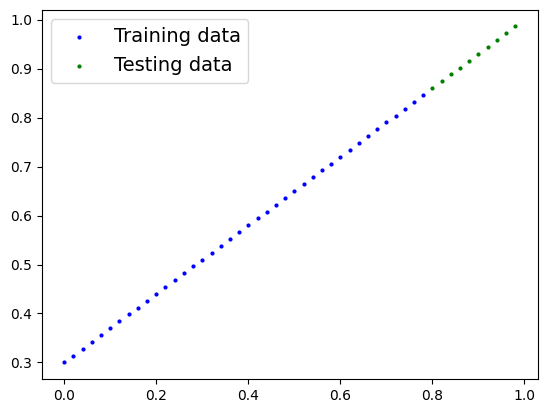

In [11]:
plot_predictions()

## Build model

Our first PyTorch Model

What our model does?
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight and bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. Gradient Descent
2. Backpropogation

In [13]:
from torch import nn

# Create a linear regression model class
class LinearRegressionModel(nn.Module):     # <- almost everything in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
    
    # Forward method to define the computations in the model
    def forward(self, x:torch.Tensor) -> torch.Tensor:      # "x" is the input data
        return self.weights * x + self*bias     # linear regression formula

### PyTorch model building essentials:

* torch.nn - contains all the buildings of the computational graph (neural networks)
* torch.nn.Parameter - what parameters a model should try and learn, often a PyTorch layer from torch.nn will set these for us.
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward().
* torch.optim - this is where optimizers in PyTorch live, they will help with gradient descent
* def forward() - All nn.Module subclasses require us to overwrite the forward(), this method defines what happens in the forward computation.